In [ ]:
# Árbol de clasificación binaria - Videojuegos

En este notebook se presenta el modelo de **árbol de decisión para clasificación binaria** en dos escenarios:

1. **Datos sintéticos**: usados en la fase exploratoria para validar el comportamiento del modelo.
2. **Datos reales**: usados en la fase final, cargados desde PostgreSQL.

In [5]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import RandomOverSampler

In [ ]:
## Parte A. Árbol de clasificación binaria con datos sintéticos

In [6]:
df = pd.read_csv("../data/videojuegos_sinteticos.csv")

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1000, 10)


,release_year,metascore,price_usd,hours_gameplay,marketing_score,social_hype,discount_pct,bugs_reported,rating_count,rating
0,2021,57.66,45.80,20.71,25.16,16.06,59.39,10,2921,50.00
1,2018,66.93,51.19,50.60,12.59,21.77,24.41,6,1667,51.68
2,2025,59.16,26.25,37.40,9.18,14.66,0.66,6,1090,50.00
3,2022,72.84,38.65,15.34,9.54,9.44,10.19,3,1079,53.04
4,2019,76.17,54.53,113.23,14.37,63.59,39.15,9,2816,64.44


In [7]:
umbral = 65
df["rating_bin"] = (df["rating"] >= umbral).astype(int)

print("Variable binaria creada correctamente")
print("\nDefinición:")
print("1 = rating alto (>= 65)")
print("0 = rating menor a 65")

print("\nConteo por clase:")
print(df["rating_bin"].value_counts().sort_index())

print("\nProporción por clase:")
print(df["rating_bin"].value_counts(normalize=True).sort_index().round(4))

Variable binaria creada correctamente

Definición:
1 = rating alto (>= 65)
0 = rating menor a 65

Conteo por clase:
rating_bin
0    814
1    186
Name: count, dtype: int64

Proporción por clase:
rating_bin
0    0.814
1    0.186
Name: proportion, dtype: float64


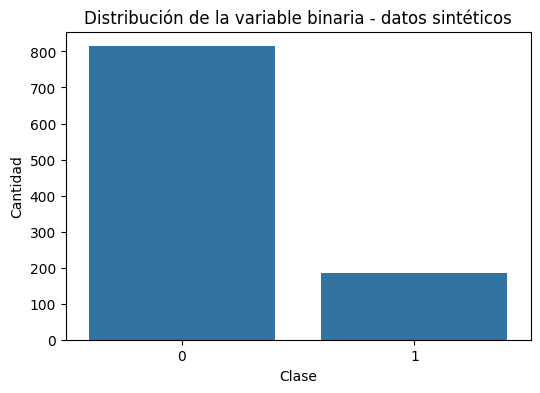

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="rating_bin", data=df)
plt.title("Distribución de la variable binaria - datos sintéticos")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

In [9]:
X_bin = df[[
    "metascore",
    "price_usd",
    "hours_gameplay",
    "social_hype",
    "discount_pct",
    "bugs_reported",
    "rating_count"
]]

y_bin = df["rating_bin"]

print("Variables independientes:")
print(X_bin.columns.tolist())
print("\nVariable dependiente:")
print("rating_bin")
print("\nForma de X:", X_bin.shape)
print("Forma de y:", y_bin.shape)

Variables independientes:
['metascore', 'price_usd', 'hours_gameplay', 'social_hype', 'discount_pct', 'bugs_reported', 'rating_count']

Variable dependiente:
rating_bin

Forma de X: (1000, 7)
Forma de y: (1000,)


In [10]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

print("Entrenamiento X:", X_train_b.shape)
print("Prueba X:", X_test_b.shape)
print("Entrenamiento y:", y_train_b.shape)
print("Prueba y:", y_test_b.shape)

print("\nDistribución entrenamiento:")
print(y_train_b.value_counts(normalize=True).sort_index().round(4))

print("\nDistribución prueba:")
print(y_test_b.value_counts(normalize=True).sort_index().round(4))

Entrenamiento X: (800, 7)
Prueba X: (200, 7)
Entrenamiento y: (800,)
Prueba y: (200,)

Distribución entrenamiento:
rating_bin
0    0.8138
1    0.1862
Name: proportion, dtype: float64

Distribución prueba:
rating_bin
0    0.815
1    0.185
Name: proportion, dtype: float64


In [11]:
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train_b, y_train_b)

y_pred_tree_bin = tree_clf.predict(X_test_b)
y_prob_tree_bin = tree_clf.predict_proba(X_test_b)[:, 1]

In [12]:
acc_tree_bin = accuracy_score(y_test_b, y_pred_tree_bin)
prec_tree_bin = precision_score(y_test_b, y_pred_tree_bin, zero_division=0)
rec_tree_bin = recall_score(y_test_b, y_pred_tree_bin, zero_division=0)
f1_tree_bin = f1_score(y_test_b, y_pred_tree_bin, zero_division=0)

print("ÁRBOL DE CLASIFICACIÓN BINARIA - MODELO BASE")
print("Accuracy:", round(acc_tree_bin, 4))
print("Precision:", round(prec_tree_bin, 4))
print("Recall:", round(rec_tree_bin, 4))
print("F1-score:", round(f1_tree_bin, 4))

ÁRBOL DE CLASIFICACIÓN BINARIA - MODELO BASE
Accuracy: 0.89
Precision: 0.7778
Recall: 0.5676
F1-score: 0.6562


Matriz de confusión:
[[157   6]
 [ 16  21]]


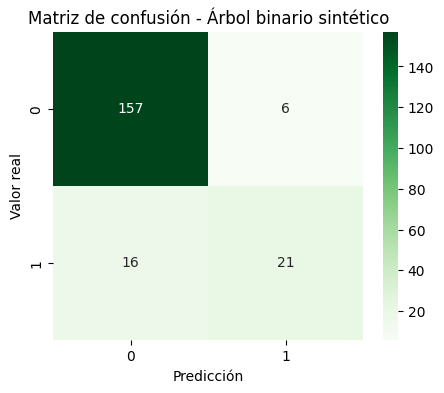

In [13]:
cm_tree_bin = confusion_matrix(y_test_b, y_pred_tree_bin)
print("Matriz de confusión:")
print(cm_tree_bin)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree_bin, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión - Árbol binario sintético")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

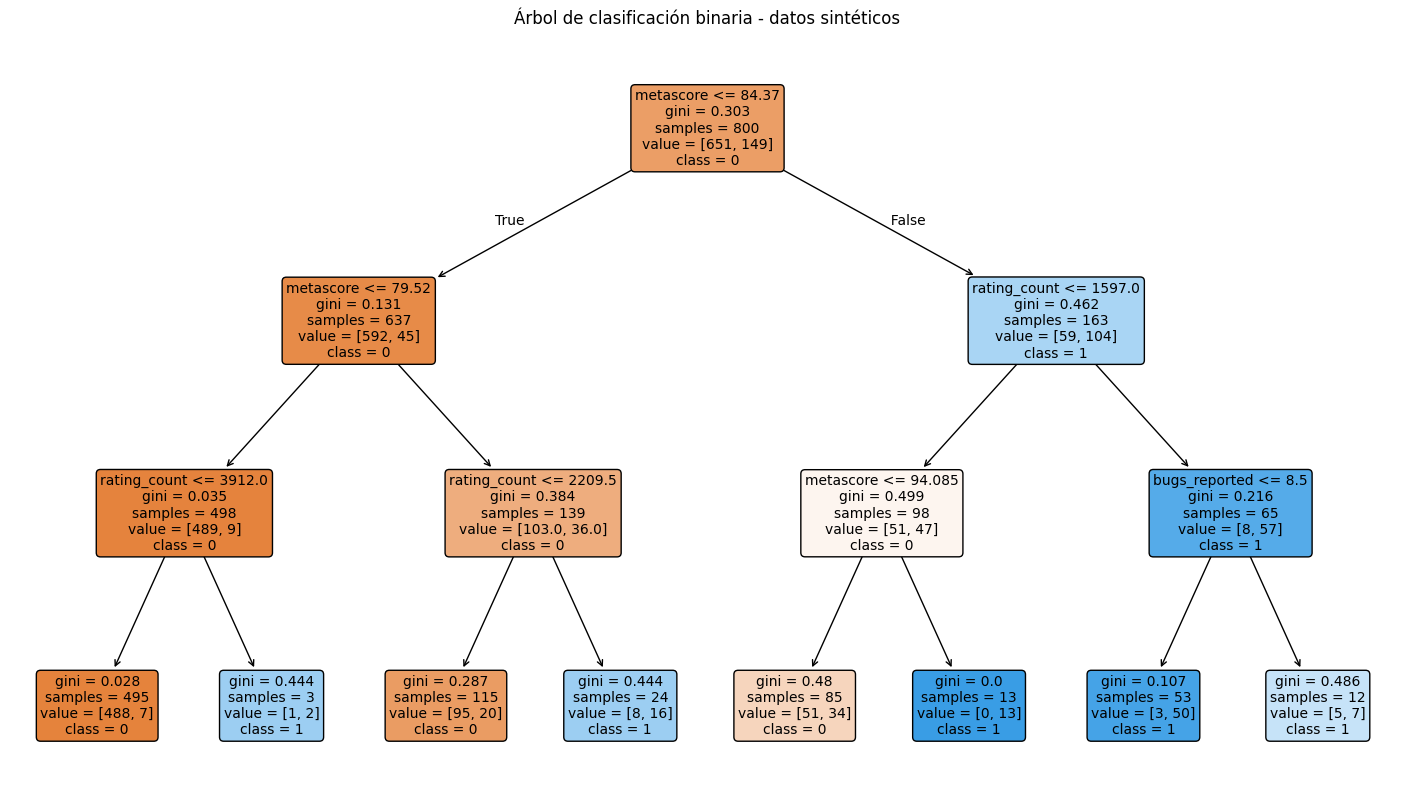

In [14]:
plt.figure(figsize=(18,10))
plot_tree(
    tree_clf,
    feature_names=X_bin.columns,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de clasificación binaria - datos sintéticos")
plt.show()

In [15]:
reglas_tree_bin = export_text(tree_clf, feature_names=list(X_bin.columns))
print("REGLAS DE DECISIÓN - ÁRBOL DE CLASIFICACIÓN BINARIA SINTÉTICO")
print(reglas_tree_bin)

REGLAS DE DECISIÓN - ÁRBOL DE CLASIFICACIÓN BINARIA SINTÉTICO
|--- metascore <= 84.37
|   |--- metascore <= 79.52
|   |   |--- rating_count <= 3912.00
|   |   |   |--- class: 0
|   |   |--- rating_count >  3912.00
|   |   |   |--- class: 1
|   |--- metascore >  79.52
|   |   |--- rating_count <= 2209.50
|   |   |   |--- class: 0
|   |   |--- rating_count >  2209.50
|   |   |   |--- class: 1
|--- metascore >  84.37
|   |--- rating_count <= 1597.00
|   |   |--- metascore <= 94.09
|   |   |   |--- class: 0
|   |   |--- metascore >  94.09
|   |   |   |--- class: 1
|   |--- rating_count >  1597.00
|   |   |--- bugs_reported <= 8.50
|   |   |   |--- class: 1
|   |   |--- bugs_reported >  8.50
|   |   |   |--- class: 1



In [16]:
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train_b, y_train_b)

print("Distribución después de oversampling:")
print(y_train_over.value_counts().sort_index())

print("\nProporción después de oversampling:")
print(y_train_over.value_counts(normalize=True).sort_index().round(4))

Distribución después de oversampling:
rating_bin
0    651
1    651
Name: count, dtype: int64

Proporción después de oversampling:
rating_bin
0    0.5
1    0.5
Name: proportion, dtype: float64


In [17]:
tree_clf_over = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_over.fit(X_train_over, y_train_over)

y_pred_tree_over = tree_clf_over.predict(X_test_b)
y_prob_tree_over = tree_clf_over.predict_proba(X_test_b)[:, 1]

In [18]:
acc_tree_over = accuracy_score(y_test_b, y_pred_tree_over)
prec_tree_over = precision_score(y_test_b, y_pred_tree_over, zero_division=0)
rec_tree_over = recall_score(y_test_b, y_pred_tree_over, zero_division=0)
f1_tree_over = f1_score(y_test_b, y_pred_tree_over, zero_division=0)

print("ÁRBOL BINARIO + OVERSAMPLING")
print("Accuracy:", round(acc_tree_over, 4))
print("Precision:", round(prec_tree_over, 4))
print("Recall:", round(rec_tree_over, 4))
print("F1-score:", round(f1_tree_over, 4))

ÁRBOL BINARIO + OVERSAMPLING
Accuracy: 0.9
Precision: 0.6667
Recall: 0.9189
F1-score: 0.7727


Matriz de confusión:
[[146  17]
 [  3  34]]


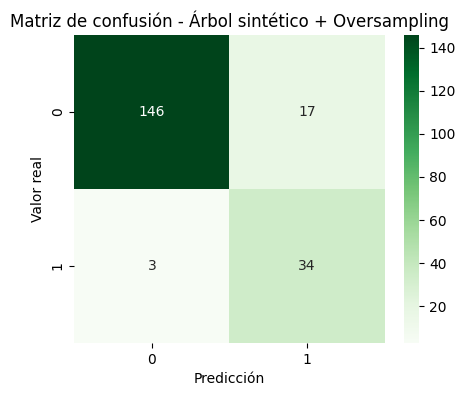

In [19]:
cm_tree_over = confusion_matrix(y_test_b, y_pred_tree_over)
print("Matriz de confusión:")
print(cm_tree_over)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree_over, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión - Árbol sintético + Oversampling")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [20]:
comparacion_arbol_sintetico = pd.DataFrame({
    "Modelo": ["Árbol base", "Árbol + Oversampling"],
    "Accuracy": [acc_tree_bin, acc_tree_over],
    "Precision": [prec_tree_bin, prec_tree_over],
    "Recall": [rec_tree_bin, rec_tree_over],
    "F1": [f1_tree_bin, f1_tree_over]
})

comparacion_arbol_sintetico.round(4)

,Modelo,Accuracy,Precision,Recall,F1
0,Árbol base,0.89,0.7778,0.5676,0.6562
1,Árbol + Oversampling,0.90,0.6667,0.9189,0.7727


In [ ]:
## Parte B. Árbol de clasificación binaria con datos reales desde PostgreSQL

In [21]:
PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Ruta agregada:", PROJECT_ROOT)

Ruta agregada: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos


In [22]:
from scripts.database import engine, test_connection

print("Conexión correcta:", test_connection())

Conexión correcta: True


In [23]:
query = "SELECT * FROM juegos_csv"
df_real = pd.read_sql(query, engine)

print("Dimensiones:", df_real.shape)
df_real.head()

Dimensiones: (99, 10)


,query,id,nombre,fecha_lanzamiento,rating,rating_count,generos,plataformas,cover_url,fecha_extraccion
0,zelda,1022,The Legend of Zelda,509328000.0,80.335612,705.0,Adventure,"Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363358
1,zelda,1025,Zelda II: The Adventure of Link,537580800.0,65.971192,289.0,"Platform, Role-playing (RPG), Adventure","Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363408
2,zelda,1041,The Legend of Zelda: Oracle of Ages,983232000.0,84.269177,164.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363427
3,zelda,1032,The Legend of Zelda: Oracle of Seasons,983232000.0,81.302509,189.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363442
4,zelda,1026,The Legend of Zelda: A Link to the Past,690681600.0,92.332359,1632.0,"Puzzle, Adventure","Satellaview, Super Nintendo Entertainment Syst...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363458


In [24]:
df_model = df_real.copy()

df_model["fecha_lanzamiento"] = pd.to_datetime(
    df_model["fecha_lanzamiento"],
    unit="s",
    errors="coerce"
)

df_model["release_year"] = df_model["fecha_lanzamiento"].dt.year

df_model["genre_count"] = (
    df_model["generos"]
    .fillna("")
    .apply(lambda x: len([g for g in str(x).split(",") if g.strip()]))
)

df_model["platform_count"] = (
    df_model["plataformas"]
    .fillna("")
    .apply(lambda x: len([p for p in str(x).split(",") if p.strip()]))
)

df_model["title_length"] = df_model["nombre"].fillna("").str.len()

print("Dimensiones antes de limpiar:", df_model.shape)
df_model[[
    "nombre", "rating", "rating_count",
    "release_year", "genre_count",
    "platform_count", "title_length"
]].head()

Dimensiones antes de limpiar: (99, 14)


,nombre,rating,rating_count,release_year,genre_count,platform_count,title_length
0,The Legend of Zelda,80.335612,705.0,1986.0,1,6,19
1,Zelda II: The Adventure of Link,65.971192,289.0,1987.0,3,5,31
2,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001.0,3,2,35
3,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001.0,3,2,38
4,The Legend of Zelda: A Link to the Past,92.332359,1632.0,1991.0,2,6,39


In [25]:
df_model = df_model.dropna(subset=["rating", "rating_count", "release_year"]).copy()

print("Dimensiones después de limpiar:", df_model.shape)
df_model[[
    "nombre", "rating", "rating_count",
    "release_year", "genre_count",
    "platform_count", "title_length"
]].head()

Dimensiones después de limpiar: (42, 14)


,nombre,rating,rating_count,release_year,genre_count,platform_count,title_length
0,The Legend of Zelda,80.335612,705.0,1986.0,1,6,19
1,Zelda II: The Adventure of Link,65.971192,289.0,1987.0,3,5,31
2,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001.0,3,2,35
3,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001.0,3,2,38
4,The Legend of Zelda: A Link to the Past,92.332359,1632.0,1991.0,2,6,39


In [26]:
umbral = 65
df_model["rating_bin"] = (df_model["rating"] >= umbral).astype(int)

print("Conteo por clase:")
print(df_model["rating_bin"].value_counts().sort_index())

print("\nProporción por clase:")
print(df_model["rating_bin"].value_counts(normalize=True).sort_index().round(4))

Conteo por clase:
rating_bin
0     8
1    34
Name: count, dtype: int64

Proporción por clase:
rating_bin
0    0.1905
1    0.8095
Name: proportion, dtype: float64


In [27]:
features_real = [
    "release_year",
    "rating_count",
    "genre_count",
    "platform_count",
    "title_length"
]

X_real_bin = df_model[features_real]
y_real_bin = df_model["rating_bin"]

print("X_real_bin:", X_real_bin.shape)
print("y_real_bin:", y_real_bin.shape)
print(y_real_bin.value_counts().sort_index())

X_real_bin: (42, 5)
y_real_bin: (42,)
rating_bin
0     8
1    34
Name: count, dtype: int64


In [28]:
X_train_real_bin, X_test_real_bin, y_train_real_bin, y_test_real_bin = train_test_split(
    X_real_bin, y_real_bin, test_size=0.2, random_state=42, stratify=y_real_bin
)

print("Entrenamiento X:", X_train_real_bin.shape)
print("Prueba X:", X_test_real_bin.shape)

print("\nDistribución entrenamiento:")
print(y_train_real_bin.value_counts().sort_index())

print("\nDistribución prueba:")
print(y_test_real_bin.value_counts().sort_index())

Entrenamiento X: (33, 5)
Prueba X: (9, 5)

Distribución entrenamiento:
rating_bin
0     6
1    27
Name: count, dtype: int64

Distribución prueba:
rating_bin
0    2
1    7
Name: count, dtype: int64


In [29]:
tree_real_bin = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_real_bin.fit(X_train_real_bin, y_train_real_bin)

y_pred_tree_real = tree_real_bin.predict(X_test_real_bin)
y_prob_tree_real = tree_real_bin.predict_proba(X_test_real_bin)[:, 1]

In [30]:
acc_tree_real = accuracy_score(y_test_real_bin, y_pred_tree_real)
prec_tree_real = precision_score(y_test_real_bin, y_pred_tree_real, zero_division=0)
rec_tree_real = recall_score(y_test_real_bin, y_pred_tree_real, zero_division=0)
f1_tree_real = f1_score(y_test_real_bin, y_pred_tree_real, zero_division=0)

print("ÁRBOL BINARIO - DATOS REALES")
print("Accuracy:", round(acc_tree_real, 4))
print("Precision:", round(prec_tree_real, 4))
print("Recall:", round(rec_tree_real, 4))
print("F1-score:", round(f1_tree_real, 4))

ÁRBOL BINARIO - DATOS REALES
Accuracy: 0.8889
Precision: 0.875
Recall: 1.0
F1-score: 0.9333


[[1 1]
 [0 7]]


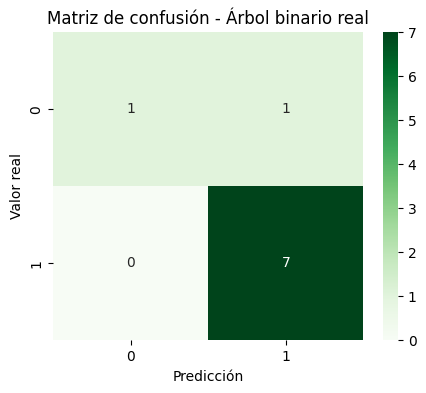

In [31]:
cm_tree_real = confusion_matrix(y_test_real_bin, y_pred_tree_real)
print(cm_tree_real)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree_real, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión - Árbol binario real")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

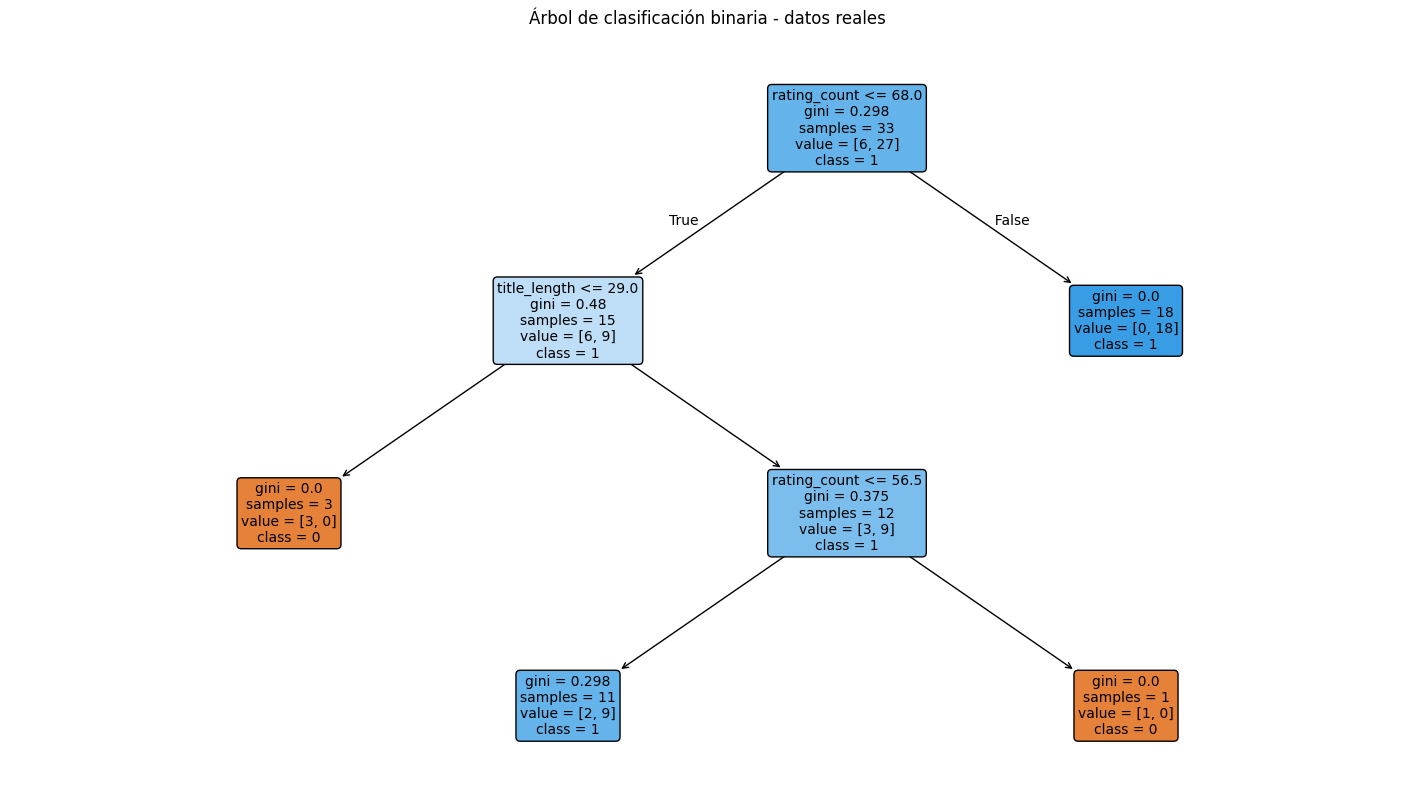

In [32]:
plt.figure(figsize=(18,10))
plot_tree(
    tree_real_bin,
    feature_names=X_real_bin.columns,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de clasificación binaria - datos reales")
plt.show()

In [33]:
reglas_tree_real = export_text(tree_real_bin, feature_names=list(X_real_bin.columns))
print("REGLAS - ÁRBOL DE CLASIFICACIÓN BINARIA REAL")
print(reglas_tree_real)

REGLAS - ÁRBOL DE CLASIFICACIÓN BINARIA REAL
|--- rating_count <= 68.00
|   |--- title_length <= 29.00
|   |   |--- class: 0
|   |--- title_length >  29.00
|   |   |--- rating_count <= 56.50
|   |   |   |--- class: 1
|   |   |--- rating_count >  56.50
|   |   |   |--- class: 0
|--- rating_count >  68.00
|   |--- class: 1



In [34]:
ros_real = RandomOverSampler(random_state=42)
X_train_real_over, y_train_real_over = ros_real.fit_resample(X_train_real_bin, y_train_real_bin)

print("Distribución después de oversampling:")
print(y_train_real_over.value_counts().sort_index())

print("\nProporción después de oversampling:")
print(y_train_real_over.value_counts(normalize=True).sort_index().round(4))

Distribución después de oversampling:
rating_bin
0    27
1    27
Name: count, dtype: int64

Proporción después de oversampling:
rating_bin
0    0.5
1    0.5
Name: proportion, dtype: float64


In [35]:
tree_real_over = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_real_over.fit(X_train_real_over, y_train_real_over)

y_pred_tree_real_over = tree_real_over.predict(X_test_real_bin)
y_prob_tree_real_over = tree_real_over.predict_proba(X_test_real_bin)[:, 1]

In [36]:
acc_tree_real_over = accuracy_score(y_test_real_bin, y_pred_tree_real_over)
prec_tree_real_over = precision_score(y_test_real_bin, y_pred_tree_real_over, zero_division=0)
rec_tree_real_over = recall_score(y_test_real_bin, y_pred_tree_real_over, zero_division=0)
f1_tree_real_over = f1_score(y_test_real_bin, y_pred_tree_real_over, zero_division=0)

print("ÁRBOL REAL + OVERSAMPLING")
print("Accuracy:", round(acc_tree_real_over, 4))
print("Precision:", round(prec_tree_real_over, 4))
print("Recall:", round(rec_tree_real_over, 4))
print("F1-score:", round(f1_tree_real_over, 4))

ÁRBOL REAL + OVERSAMPLING
Accuracy: 0.7778
Precision: 0.7778
Recall: 1.0
F1-score: 0.875


[[0 2]
 [0 7]]


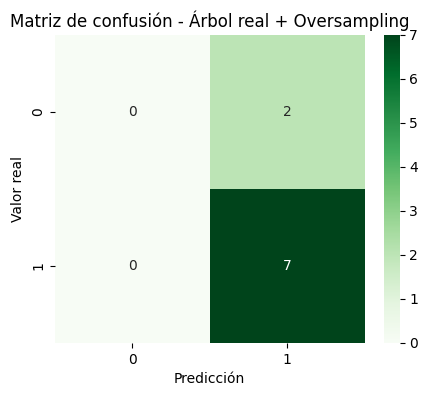

In [37]:
cm_tree_real_over = confusion_matrix(y_test_real_bin, y_pred_tree_real_over)
print(cm_tree_real_over)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree_real_over, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión - Árbol real + Oversampling")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [38]:
comparacion_arbol_real = pd.DataFrame({
    "Modelo": ["Árbol binario real", "Árbol real + Oversampling"],
    "Accuracy": [acc_tree_real, acc_tree_real_over],
    "Precision": [prec_tree_real, prec_tree_real_over],
    "Recall": [rec_tree_real, rec_tree_real_over],
    "F1": [f1_tree_real, f1_tree_real_over]
})

comparacion_arbol_real.round(4)

,Modelo,Accuracy,Precision,Recall,F1
0,Árbol binario real,0.8889,0.8750,1.0,0.9333
1,Árbol real + Oversampling,0.7778,0.7778,1.0,0.8750


In [ ]:
# Conclusión

En este notebook se aplicó el modelo de **árbol de decisión para clasificación binaria** en dos contextos:

- **Datos sintéticos**, usados en la etapa exploratoria para validar el comportamiento del modelo.
- **Datos reales**, cargados desde PostgreSQL, usados en la etapa final del proyecto.

En ambos casos se construyó la variable `rating_bin` para clasificar videojuegos en dos clases.  
También se comparó el modelo base frente a una versión con **oversampling**, con el fin de analizar el efecto del balanceo de clases.

Los resultados con datos reales deben interpretarse con cautela, ya que la muestra disponible fue más pequeña y específica que la sintética.